### https://www.kaggle.com/competitions/drawing-with-llms

In [1]:
import kagglehub
import pandas as pd
import sys
sys.path.append('./utils')

In [2]:
import concurrent
import io
import logging
import re
import re2

import cairosvg
import kagglehub
import torch
from lxml import etree
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

import svg_constraints 

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('DEVICE', DEVICE)

class SVGSanitizer:
    def __init__(self, constraints, default_svg):
        self.constraints = constraints
        self.default_svg = default_svg
    
    def enforce_constraints(self, svg_string: str) -> str:
        """Enforces constraints on an SVG string, removing disallowed elements
        and attributes.

        Parameters
        ----------
        svg_string : str
            The SVG string to process.

        Returns
        -------
        str
            The processed SVG string, or the default SVG if constraints
            cannot be satisfied.
        """
        logging.info('Sanitizing SVG...')

        try:
            parser = etree.XMLParser(remove_blank_text=True, remove_comments=True)
            root = etree.fromstring(svg_string, parser=parser)
        except etree.ParseError as e:
            logging.error('SVG Parse Error: %s. Returning default SVG.', e)
            return self.default_svg
    
        elements_to_remove = []
        for element in root.iter():
            try:
                tag_name = etree.QName(element.tag).localname
            except ValueError as e:
                return self.default_svg
    
            # Remove disallowed elements
            if tag_name not in self.constraints.allowed_elements:
                elements_to_remove.append(element)
                continue  # Skip attribute checks for removed elements
    
            # Remove disallowed attributes
            attrs_to_remove = []
            for attr in element.attrib:
                attr_name = etree.QName(attr).localname
                if (
                    attr_name
                    not in self.constraints.allowed_elements[tag_name]
                    and attr_name
                    not in self.constraints.allowed_elements['common']
                ):
                    attrs_to_remove.append(attr)
    
            for attr in attrs_to_remove:
                logging.debug(
                    'Attribute "%s" for element "%s" not allowed. Removing.',
                    attr,
                    tag_name,
                )
                del element.attrib[attr]
    
            # Check and remove invalid href attributes
            for attr, value in element.attrib.items():
                 if etree.QName(attr).localname == 'href' and not value.startswith('#'):
                    logging.debug(
                        'Removing invalid href attribute in element "%s".', tag_name
                    )
                    del element.attrib[attr]

            # Validate path elements to help ensure SVG conversion
            if tag_name == 'path':
                d_attribute = element.get('d')
                if not d_attribute:
                    logging.warning('Path element is missing "d" attribute. Removing path.')
                    elements_to_remove.append(element)
                    continue # Skip further checks for this removed element
                # Use regex to validate 'd' attribute format
                path_regex = re2.compile(
                    r'^'  # Start of string
                    r'(?:'  # Non-capturing group for each command + numbers block
                    r'[MmZzLlHhVvCcSsQqTtAa]'  # Valid SVG path commands (adjusted to exclude extra letters)
                    r'\s*'  # Optional whitespace after command
                    r'(?:'  # Non-capturing group for optional numbers
                    r'-?\d+(?:\.\d+)?(?:[Ee][+-]?\d+)?'  # First number
                    r'(?:[\s,]+-?\d+(?:\.\d+)?(?:[Ee][+-]?\d+)?)*'  # Subsequent numbers with mandatory separator(s)
                    r')?'  # Numbers are optional (e.g. for Z command)
                    r'\s*'  # Optional whitespace after numbers/command block
                    r')+'  # One or more command blocks
                    r'\s*'  # Optional trailing whitespace
                    r'$'  # End of string
                )
                if not path_regex.match(d_attribute):
                    logging.warning(
                        'Path element has malformed "d" attribute format. Removing path.'
                    )
                    elements_to_remove.append(element)
                    continue
                logging.debug('Path element "d" attribute validated (regex check).')
        
        # Remove elements marked for removal
        for element in elements_to_remove:
            if element.getparent() is not None:
                element.getparent().remove(element)
                logging.debug('Removed element: %s', element.tag)

        try:
            cleaned_svg_string = etree.tostring(root, encoding='unicode')
            return cleaned_svg_string
        except ValueError as e:
            logging.error(
                'SVG could not be sanitized to meet constraints: %s', e
            )
            return self.default_svg

class SVGProcessor:
    @staticmethod
    def clean_and_extract_svgs(text, default_svg):
        text = re.sub(r'^.*?(<svg\b)', r'\1', text, flags=re.DOTALL)
        svg_blocks = re.findall(r'<svg\b.*?</svg>', text, re.DOTALL)
    
        if svg_blocks:
            tmp = re.findall(r'<svg\b.*?', svg_blocks[-1], re.DOTALL)
            if len(tmp) > 1:
                tmp2 = svg_blocks[-1].split('<svg')
                return '<svg ' + tmp2[-1]
            else:
                return svg_blocks[-1]
        else:
            if "<svg" in text and "</svg>" not in text:
                text += "</svg>"
                return text
            return default_svg
    
    @staticmethod
    def svg_conversion_check(topic, base_svg_code, default_svg):
        try:
            cairosvg.svg2png(bytestring=base_svg_code.encode('utf-8'), write_to="temp.png")
            return base_svg_code
        except Exception as e:
            print(f"Failed to convert {topic} due to {str(e)}, Returning default SVG.")
            return default_svg


class Model:
    def __init__(self):
        self.model="model"
        
        self.default_svg = """<svg width="256" height="256" viewBox="0 0 256 256"><circle cx="50" cy="50" r="40" fill="red" /></svg>"""
        self.constraints = svg_constraints.SVGConstraints()
        self.sanitizer = SVGSanitizer(self.constraints, self.default_svg)
        
    def clean_svg(self, base_svg_code: str, max_new_tokens=1024) -> str:
        base_svg_code = SVGProcessor.clean_and_extract_svgs(base_svg_code, self.default_svg)
        clean_svg_code = self.sanitizer.enforce_constraints(base_svg_code)
        return clean_svg_code


DEVICE cuda


In [3]:
model=Model()

### Response Loader from CSV batch files

In [4]:
import os
import pandas as pd

# Directory containing CSV files
csv_dir = './batches_async/third_300_batches_gemini_20_flash'

# Get list of all CSV files in the directory
csv_files = [f for f in os.listdir(csv_dir) if f.endswith('.csv')]

# Read and combine them
df_list = [pd.read_csv(os.path.join(csv_dir, file)) for file in csv_files]
combined_df = pd.concat(df_list, ignore_index=True)

df=combined_df.copy()
print(df.shape)

(28071, 3)


In [5]:
df.head()

,description,gemini_response_text,gemini_error
0,expressive brushstrokes capturing movement,"```xml\n<svg width=""200"" height=""200"" viewBox=...",NaN
1,a silver lamé jumpsuit,"```xml\n<svg width=""200"" height=""300"" viewBox=...",NaN
2,a lush oasis in the middle of the desert,"```xml\n<svg width=""200"" height=""150"" viewBox=...",NaN
3,geometric deconstructions of familiar shapes,"```xml\n<svg width=""200"" height=""200"" viewBox=...",NaN
4,a hot pink mini skirt,"```xml\n<svg width=""200"" height=""200"" viewBox=...",NaN


In [6]:
import re
def extract_from_gemini_response(text):
    try:
        pattern = r'```xml\n(.*?)\n```'
        
        # Search for the pattern
        match = re.search(pattern, text, re.DOTALL)
        
        # Check if a match was found and extract the SVG code
        if match:
            svg_code = match.group(1).strip() # .strip() removes leading/trailing whitespace
            return svg_code
        else:
            print("SVG code block not found in the string.")
            return 0 
    except Exception as e:
        return 0

In [7]:
from tqdm import tqdm
tqdm.pandas()
df['extracted_svg'] = df['gemini_response_text'].progress_apply(lambda x: extract_from_gemini_response(x))
df=df[df['extracted_svg']!=0]
print(df.shape)

 33%|███████████▍                       | 9189/28071 [00:00<00:00, 91889.65it/s]

SVG code block not found in the string.
SVG code block not found in the string.
SVG code block not found in the string.
SVG code block not found in the string.
SVG code block not found in the string.
SVG code block not found in the string.
SVG code block not found in the string.
SVG code block not found in the string.
SVG code block not found in the string.


 65%|██████████████████████▎           | 18378/28071 [00:00<00:00, 91718.57it/s]

SVG code block not found in the string.
SVG code block not found in the string.
SVG code block not found in the string.
SVG code block not found in the string.
SVG code block not found in the string.


100%|██████████████████████████████████| 28071/28071 [00:00<00:00, 91135.21it/s]

SVG code block not found in the string.
SVG code block not found in the string.
SVG code block not found in the string.
SVG code block not found in the string.
SVG code block not found in the string.
SVG code block not found in the string.
SVG code block not found in the string.
SVG code block not found in the string.
(28046, 4)


In [8]:
from tqdm import tqdm
tqdm.pandas()
df['cleaned_svg'] = df['extracted_svg'].progress_apply(lambda x: model.clean_svg(x))
df=df[df['cleaned_svg']!=0]
print(df.shape)

ERROR:root:SVG Parse Error: Attribute y redefined, line 23, column 73 (<string>, line 23). Returning default SVG.
ERROR:root:SVG Parse Error: Attribute stroke-width redefined, line 16, column 92 (<string>, line 16). Returning default SVG.
ERROR:root:SVG Parse Error: Attribute y1 redefined, line 10, column 74 (<string>, line 10). Returning default SVG.
ERROR:root:SVG Parse Error: Attribute y1 redefined, line 6, column 74 (<string>, line 6). Returning default SVG.
ERROR:root:SVG Parse Error: Attribute stroke redefined, line 17, column 143 (<string>, line 17). Returning default SVG.
ERROR:root:SVG Parse Error: Attribute y1 redefined, line 14, column 75 (<string>, line 14). Returning default SVG.
ERROR:root:SVG Parse Error: Attribute y redefined, line 24, column 76 (<string>, line 24). Returning default SVG.
ERROR:root:SVG Parse Error: Attribute stroke redefined, line 14, column 126 (<string>, line 14). Returning default SVG.
ERROR:root:SVG Parse Error: Attribute y1 redefined, line 17, col

(28046, 5)


In [9]:
df['gemini_response_text'].iloc[0]

'```xml\n<svg width="200" height="200" viewBox="0 0 200 200" fill="none" xmlns="http://www.w3.org/2000/svg">\n  <defs>\n    <linearGradient id="paintGradient" x1="0" y1="0" x2="1" y2="1" gradientUnits="userSpaceOnUse">\n      <stop stop-color="#E91E63"/>\n      <stop offset="1" stop-color="#9C27B0"/>\n    </linearGradient>\n  </defs>\n  <path d="M20 50 C 50 20 80 80 100 50 C 120 20 150 80 180 50" stroke="url(#paintGradient)" stroke-width="8" stroke-linecap="round"/>\n  <path d="M20 100 C 50 70 80 130 100 100 C 120 70 150 130 180 100" stroke="url(#paintGradient)" stroke-width="6" stroke-linecap="round"/>\n  <path d="M20 150 C 50 120 80 180 100 150 C 120 120 150 180 180 150" stroke="url(#paintGradient)" stroke-width="4" stroke-linecap="round"/>\n  <path d="M30 75 C 60 45 90 105 110 75 C 130 45 160 105 190 75" stroke="#673AB7" stroke-width="2" stroke-linecap="round" opacity="0.7"/>\n  <path d="M30 125 C 60 95 90 155 110 125 C 130 95 160 155 190 125" stroke="#673AB7" stroke-width="2" strok

### Topic Loader from txt batch files

In [1]:
import sys
sys.path.append('./utils')
from siglip_class import SVGMetricEvaluator
from aesthetic_evaluator import AestheticEvaluator

In [2]:
from concurrent.futures import ThreadPoolExecutor, TimeoutError
import pandas as pd
from tqdm import tqdm
tqdm.pandas()
# Initialize evaluator
evaluator = SVGMetricEvaluator()
aes_eval = AestheticEvaluator()

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [3]:
def safe_svg_metric(prompt, svg, timeout=10):
    with ThreadPoolExecutor(max_workers=1) as executor:
        future = executor.submit(evaluator.svg_metric, prompt, svg)
        try:
            return future.result(timeout=timeout)
        except TimeoutError:
            print("Timeout: Skipping slow SVG evaluation.")
            return 0
        except Exception as e:
            print(f"Error: {e}")
            return 0

def safe_aes_eval(svg, timeout=10):
    with ThreadPoolExecutor(max_workers=1) as executor:
        future = executor.submit(aes_eval.get_score, svg)
        try:
            return future.result(timeout=timeout)
        except TimeoutError:
            print("Timeout: Skipping slow SVG evaluation.")
            return 0
        except Exception as e:
            print(f"Error: {e}")
            return 0

In [13]:
# # Apply with tqdm and timeout-aware function
# df['gemini_extracted_svg_sl_score'] = df.progress_apply(
#     lambda row: safe_svg_metric(row['description'], row['extracted_svg']), axis=1
# )

In [4]:
df=pd.read_csv('./drawing-with-llms/train_master_4_batch_svg_dataset_scored_11k.csv')

In [5]:
df.head()

,sentence,best_image_score,svg_code
0,An indigo hexagon bloom glistens with morning ...,0.9801,"<svg xmlns=""http://www.w3.org/2000/svg"" clip-r..."
1,Sharp mountain silhouettes stand amidst a grad...,0.9849,"<svg xmlns=""http://www.w3.org/2000/svg"" clip-r..."
2,A tree composed of interlocking hexagons stand...,0.9965,"<svg xmlns=""http://www.w3.org/2000/svg"" clip-r..."
3,Lavender desert stretching endlessly under moo...,0.9975,"<svg xmlns=""http://www.w3.org/2000/svg"" clip-r..."
4,"A gradient amber, peach, and cobalt sky over e...",0.9997,"<svg xmlns=""http://www.w3.org/2000/svg"" clip-r..."


In [6]:
# Apply with tqdm and timeout-aware function
df['gemini_cleaned_svg_sl_score'] = df.progress_apply(
    lambda row: safe_svg_metric(row['sentence'], row['svg_code']), axis=1
)

 56%|█████████████████████▎                | 6286/11188 [06:30<01:52, 43.67it/s]

An error occurred: 'float' object has no attribute 'encode'
An error occurred: 'float' object has no attribute 'encode'
An error occurred: 'float' object has no attribute 'encode'
An error occurred: 'float' object has no attribute 'encode'
An error occurred: 'float' object has no attribute 'encode'
An error occurred: 'float' object has no attribute 'encode'
An error occurred: 'float' object has no attribute 'encode'
An error occurred: 'float' object has no attribute 'encode'
An error occurred: 'float' object has no attribute 'encode'
An error occurred: 'float' object has no attribute 'encode'
An error occurred: 'float' object has no attribute 'encode'
An error occurred: 'float' object has no attribute 'encode'


 98%|████████████████████████████████████▎| 10987/11188 [11:25<00:06, 29.67it/s]

An error occurred: 'float' object has no attribute 'encode'
An error occurred: 'float' object has no attribute 'encode'
An error occurred: 'float' object has no attribute 'encode'
An error occurred: 'float' object has no attribute 'encode'
An error occurred: 'float' object has no attribute 'encode'
An error occurred: 'float' object has no attribute 'encode'


100%|█████████████████████████████████████| 11188/11188 [11:38<00:00, 16.01it/s]


In [17]:
# # Apply with tqdm and timeout-aware function
# df['gemini_extracted_svg_aes_score'] = df.progress_apply(
#     lambda row: safe_aes_eval(row['extracted_svg']), axis=1
# )

<Axes: >

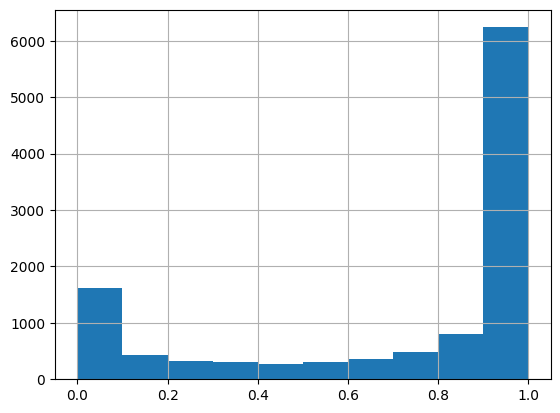

In [8]:
df['gemini_cleaned_svg_sl_score'].hist()

In [10]:
df[df['gemini_cleaned_svg_sl_score'] > 0.5].to_csv('11k_dataset_cleaned.csv',index=False)

In [11]:
df[df['gemini_cleaned_svg_sl_score'] > 0.5].shape

(8206, 4)

In [19]:
# Apply with tqdm and timeout-aware function
df['gemini_cleaned_svg_aes_score'] = df.progress_apply(
    lambda row: safe_aes_eval(row['cleaned_svg']), axis=1
)

 14%|█████▍                                | 4011/28046 [06:38<33:41, 11.89it/s]

Errror in scoring: return 0.00


 15%|█████▌                                | 4146/28046 [06:51<33:51, 11.77it/s]

Errror in scoring: return 0.00


 16%|█████▉                                | 4390/28046 [07:15<32:37, 12.09it/s]

...

 98%|████████████████████████████████████▏| 27388/28046 [45:09<00:54, 12.14it/s]

Errror in scoring: return 0.00


 98%|████████████████████████████████████▏| 27431/28046 [45:13<00:50, 12.19it/s]

Errror in scoring: return 0.00


100%|█████████████████████████████████████| 28046/28046 [46:14<00:00, 10.11it/s]


In [21]:
#combined score
#df['combined_score'] = (df['gemini_sl_score']+df['gemini_sl_score']+df['gemini_aes_score'])/3

In [22]:
#print('Mean SL Score:',df['gemini_sl_score'].mean())

In [23]:
#print('Mean AES Score:',df['gemini_aes_score'].mean())

In [24]:
#df[df['gemini_sl_score'] >= 0.5].shape

### Async version is actually slower, why?

In [26]:
# import asyncio
# import nest_asyncio
# import pandas as pd
# from tqdm import tqdm
# from concurrent.futures import ThreadPoolExecutor

# nest_asyncio.apply()

# # Evaluators
# evaluator = SVGMetricEvaluator()
# aes_eval = AestheticEvaluator()

# # Function to evaluate one row
# def evaluate_row(row):
#     description = row['description']
#     extracted_svg = row['extracted_svg']
#     cleaned_svg = row['cleaned_svg']
    
#     return {
#         'gemini_extracted_svg_sl_score': evaluator.svg_metric(description, extracted_svg),
#         'gemini_cleaned_svg_sl_score': evaluator.svg_metric(description, cleaned_svg),
#         'gemini_extracted_svg_aes_score': aes_eval.get_score(extracted_svg),
#         'gemini_cleaned_svg_aes_score': aes_eval.get_score(cleaned_svg)
#     }

# # Async processor
# async def process_dataframe_async(df, max_workers=8):
#     loop = asyncio.get_event_loop()
#     results = []
    
#     with ThreadPoolExecutor(max_workers=max_workers) as executor:
#         tasks = [
#             loop.run_in_executor(executor, evaluate_row, row)
#             for _, row in df.iterrows()
#         ]
#         for result in tqdm(asyncio.as_completed(tasks), total=len(tasks)):
#             results.append(await result)
    
#     return results

# # Run and merge results
# results = await process_dataframe_async(df)
# results_df = pd.DataFrame(results)
# df = pd.concat([df.reset_index(drop=True), results_df], axis=1)

In [32]:
#df[df['gemini_cleaned_svg_sl_score'] >0.5].to_csv('gemini_filterd.csv',index=False)